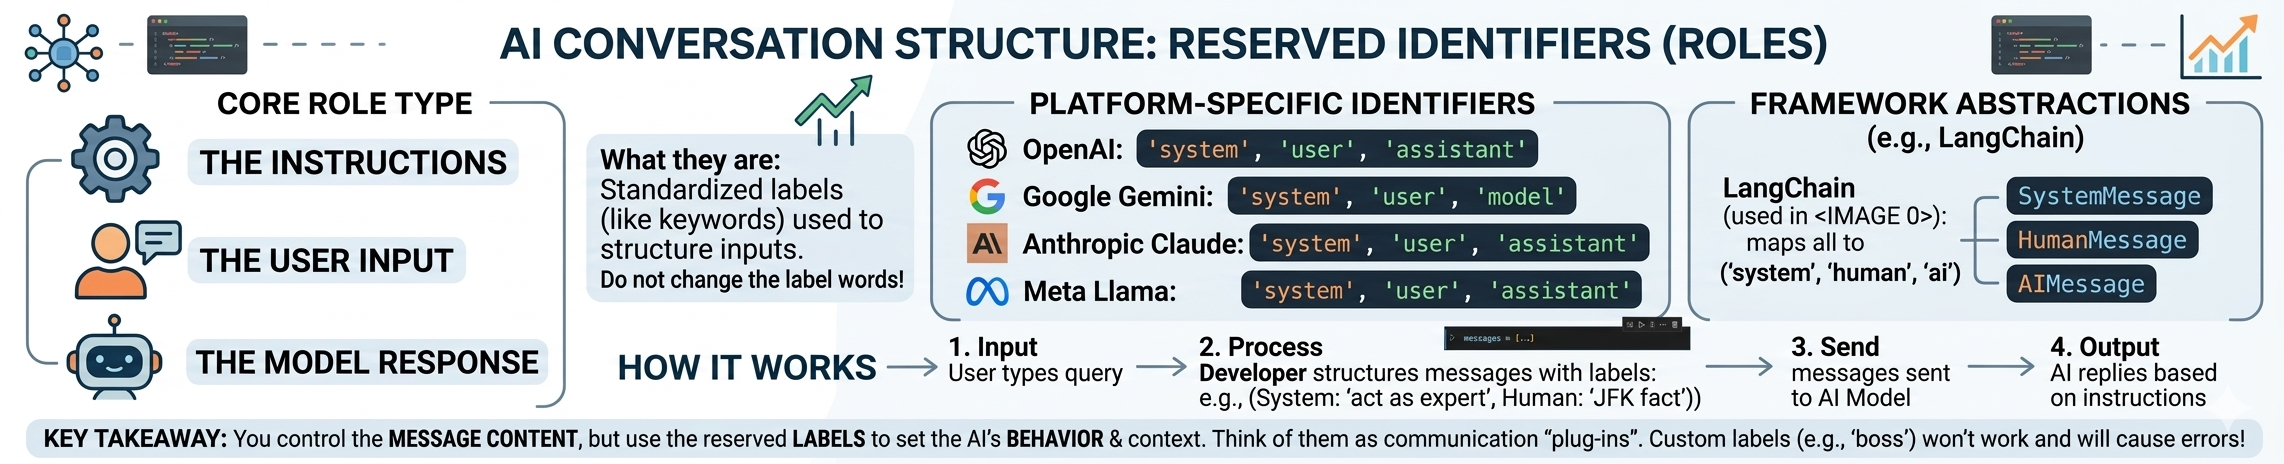

In [ ]:
# 1. Install zstd (Required for extraction) and LangChain libraries
!sudo apt-get update && sudo apt-get install -y zstd
!pip install langchain-ollama langchain-community
!sudo systemctl enable --now ollama
# 2. Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [61.6 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,862 

In [ ]:
# 1. Install Ollama and the Python library
!curl -fsSL https://ollama.com/install.sh | sh
!pip install ollama -q

import subprocess
import time
import threading
import ollama

# 2. Start Ollama server in the background
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)  # Give the server a moment to warm up

# 3. Pull a odel (Llama 3.2 is ~2GB)
print("Downloading model...")
ollama.pull('llama3.2')

# 4. Ask a simple question
print("\n--- Model Response ---")
response = ollama.chat(model='llama3.2', messages=[
    {'role': 'user', 'content': 'What is the most interesting fact about space?'}
])

print(response['message']['content'])

Without roles

In [ ]:
import ollama

response = ollama.chat(
    model='llama3.2',
    messages=[
        {"role": "user", "content": "What you mean by an index"}
    ]
)

print(response['message']['content'])

✅ With system role

In [ ]:
import ollama

response = ollama.chat(
    model='llama3.2',
    messages=[
        {"role": "system", "content": "You are a Data Engineer. Give short, practical explanations with real-world examples."},
        {"role": "user", "content": "What you mean by an index"}
    ]
)

print(response['message']['content'])

In [ ]:
import ollama

response = ollama.chat(
    model='llama3.2',
    messages=[
        {"role": "user", "content": "What is normalization in databases?"},
        {"role": "assistant", "content": "Normalization is organizing data to reduce redundancy."},
        {"role": "user", "content": "Explain it with an example"}
    ]
)

print(response['message']['content'])

In [ ]:
import ollama
import psutil

# Step 1: Define a tool (reads actual CPU usage)
def get_cpu_usage():
    usage = psutil.cpu_percent(interval=1)
    return f"CPU usage is {usage}%"

# Step 2: Initial user query
messages = [
    {"role": "system", "content": "You are a DevOps Engineer. Use tools for system info."},
    {"role": "user", "content": "Is my system under heavy load right now?"}
]

# Step 3: First model response
response = ollama.chat(model='llama3.2', messages=messages)

# Step 4: Decide to call tool (basic logic)
tool_result = get_cpu_usage()

# Add assistant + tool messages
messages.append(response['message'])
messages.append({"role": "tool", "content": tool_result})

# Step 5: Final response using REAL data
final_response = ollama.chat(model='llama3.2', messages=messages)

print(final_response['message']['content'])

In [ ]:
# Developer instructions act as 'Product Guardrails' above the System prompt.

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

llm = ChatOllama(model="llama3.2")

# 1. System: The "What I am" (Core Identity)
# 2. Developer: The "How I must behave for this app" (Instruction Layer)
# 3. User: The "What I want right now" (The Task)

messages = [
    # System Role: High-level persona
    SystemMessage(content="You are a professional legal translator."),

    # Developer Role: Often passed as a System/Instruction message
    # but serves as the 'App Rules' layer.
    SystemMessage(content="DEVELOPER_INSTRUCTIONS: Output ONLY the translation. Do not include 'Here is the translation'. Use formal vocabulary only."),

    # User Role: The specific input
    HumanMessage(content="Translate 'The party of the first part shall pay the party of the second part' into Spanish.")
]

response = llm.invoke(messages)
print(f"Final Output:\n{response.content}")

In [ ]:
# Operation: Baseline - The model writes simple, potentially unsafe code.

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage

llm = ChatOllama(model="llama3.2")

messages = [
    HumanMessage(content="Write a Python function to read a file named 'data.txt'.")
]

print("--- WITHOUT DEVELOPER RULES ---")
print(llm.invoke(messages).content)
# Result: Usually just 'open("data.txt").read()'.
# This is "bad" code because it doesn't handle the file being missing!

In [ ]:
# Operation: Enforcement - The Developer Layer forces the model to follow 'Senior' coding standards.

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOllama(model="llama3.2")

# THE DEVELOPER LAYER: Coding Standards
dev_rules = SystemMessage(content="""
DEVELOPER_CODING_STANDARDS:
1. ALWAYS use 'try-except' blocks for file operations.
2. ALWAYS use the 'with' statement for resource management.
3. Use Type Hinting (e.g., def func(param: str) -> str:).
4. Include a docstring starting with 'COMPANY_PROPERTY'.
5. Return the code ONLY. No explanations.
""")

messages = [
    dev_rules,
    HumanMessage(content="Write a Python function to read a file named 'data.txt'.")
]

print("--- WITH DEVELOPER RULES (SECURE CODE) ---")
print(llm.invoke(messages).content)

Model Type

In [ ]:
import subprocess
import time
import os

# 1. Install & Start Server
!curl -fsSL https://ollama.com/install.sh | sh

# Use 'nohup' to ensure the process keeps running in the background
process = subprocess.Popen(['ollama', 'serve'],
                           env={**os.environ, "OLLAMA_HOST": "127.0.0.1:11434"},
                           stdout=subprocess.PIPE,
                           stderr=subprocess.PIPE)

# Give it more than 5 seconds - pulling a model can take time
time.sleep(10)

# 2. Verify the server is up before pulling
!ollama list

# 3. Pull and Chat
import ollama
ollama.pull('llama3.2')
response = ollama.chat(model='llama3.2', messages=[
    {'role': 'user', 'content': 'What is the most interesting fact about space?'}
])


print(response['message']['content'])
QUESTION = "Describe the Moon in one sentence."

# --- Completion Mode ---
completion_llm = OllamaLLM(model="llama3.2")
completion_answer = completion_llm.invoke(QUESTION)
print("Completion Mode Answer:\n", completion_answer)

# --- ChatModel Mode ---
chat_llm = ChatOllama(model="llama3.2")
messages = [
    SystemMessage(content="You are a poetic astronomer."),
    HumanMessage(content=QUESTION)
]
chat_answer = chat_llm.invoke(messages)
print("\nChatModel Mode Answer:\n", chat_answer.content)


In [ ]:
!pip install langchain

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_ollama import OllamaLLM

# Template with adjective slot
template = "You are a {adjective} assistant. Write one sentence about {topic}."

prompt = PromptTemplate(
    input_variables=["adjective", "topic"],
    template=template
)

# Choose one adjective + topic
formatted = prompt.format(adjective="poetic", topic="the Moon")

print("Prompt:", formatted)

# Send to model
llm = OllamaLLM(model="llama3.2")
response = llm.invoke(formatted)

print("Output:", response)


In [ ]:
from langchain_core.prompts import PromptTemplate

# Define a template with an adjective placeholder
template = """
You are a {adjective} assistant.
Answer the following question clearly:

Question: {question}
"""

prompt = PromptTemplate(
    input_variables=["adjective", "question"],
    template=template
)

QUESTION = "Describe the Moon in one sentence."

# Try 5 different adjectives
adjectives = ["helpful", "witty", "serious", "poetic", "scientific"]

for adj in adjectives:
    formatted_prompt = prompt.format(adjective=adj, question=QUESTION)
    print(f"\n--- Prompt with '{adj}' ---\n{formatted_prompt}")


In [ ]:
# Operation: Single script comparison showing 'Default' vs 'Variable-Controlled' length.

from langchain_ollama import ChatOllama
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage

llm = ChatOllama(model="llama3.2")

topic = "The Invention of the Internet"

# --- PART 1: WITHOUT LENGTH VARIABLE ---
# The model decides the length itself.
print("--- [1] WITHOUT LENGTH VARIABLE ---")
msg = HumanMessage(content=f"Summarize {topic}.")
print(llm.invoke([msg]).content)


print("\n" + "-"*30 + "\n")


# --- PART 2: WITH LENGTH VARIABLE ---
# The Developer uses a template to force a specific constraint.
print("--- [2] WITH LENGTH VARIABLE ---")

# 1. Define the template with a variable
template = """
DEVELOPER_INSTRUCTION: You are a technical writer.
Rule: You must summarize the topic in exactly {length}.
Topic: {topic}
"""

prompt = PromptTemplate(input_variables=["length", "topic"], template=template)

# 2. Show students the variables the developer has defined
print(f"Variables defined by Developer: {prompt.input_variables}")

# 3. Execute with a specific length constraint
# Change "one short sentence" to "three bullet points" to see the shift
formatted_prompt = prompt.format(length="one short sentence", topic=topic)
response = llm.invoke(formatted_prompt)

print(f"Result (Constrained to {prompt.input_variables[0]}):")
print(response.content)

In [ ]:

# 1. Setup the Model
llm = ChatOllama(model="llama3.2")

# 2. Setup the Template
template = "You are a professional assistant. Write a one-sentence email about {topic} in a {tone} tone."
prompt = PromptTemplate(input_variables=["tone", "topic"], template=template)

# --- RUNNING THE PROFESSIONAL VERSION ---
print("--- Result: Professional ---")
prof_prompt = prompt.format(tone="formal and corporate", topic="Project Updates")
# This line actually talks to Ollama:
response_prof = llm.invoke(prof_prompt)
print(response_prof.content)

print("\n" + "-"*30 + "\n")

# --- RUNNING THE SARCASTIC VERSION ---
print("--- Result: Sarcastic ---")
sarc_prompt = prompt.format(tone="heavy sarcasm", topic="Project Updates")
# This line actually talks to Ollama:
response_sarc = llm.invoke(sarc_prompt)
print(response_sarc.content)

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import PromptTemplate

# 1. Initialize local model
llm = ChatOllama(model="llama3.2")

# 2. Setup the Template
# Rules: Hard-coded one-sentence limit. Variable for Audience.
template = "Explain the concept of {topic} in exactly one sentence for an audience of {audience}."

prompt = PromptTemplate(
    input_variables=["topic", "audience"],
    template=template
)

# 3. Execution Function
def explain_to_audience(target_audience):
    formatted = prompt.format(topic="The Internet", audience=target_audience)
    response = llm.invoke(formatted)
    print(f"AUDIENCE: {target_audience}")
    print(f"RESPONSE: {response.content}\n")

# --- Test Cases ---
# This shows how the 'Developer Instruction' forces the model to change its vocabulary
explain_to_audience("a 5-year-old child")
explain_to_audience("a Senior Software Engineer")